<a href="https://colab.research.google.com/github/AKezic/Projekt---machine-learning-model/blob/main/Projekt_AKEzic_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projekt.TOX21_NFkB_BLA_agonist_ch1





# Library

In [ ]:
pip install pandas numpy rdkit mordred scikit-learn matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.8/128.8 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.3/34.3 MB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 82.6 MB/s eta 0:00:00
  Created wheel for mordred: filename=mordred-1.2.0-py3-none-any.whl size=176718 sha256=b9f9a7cbb84d585c1062073f09cf077a75cb92f6ad13f215cad5fdb34e900089
  Stored in directory: /root/.cache/pip/wheels/8b/30/0b/84e3f6775306e74cf5957ee4d16b10bf3927dcec44cc23d5f2
Successfully built mordred
  Attempting uninstall: networkx
    Found existing installation: networkx 3.4.2
    Uninstalling networkx-3.4.2:
      Successfully uninstalled networkx-3.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
nx-cugraph-cu12 24.12.0 requires networkx>=3.2, but you have networkx 2.8.8 which is incompatible.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Chemical Informatics and Feature Engineering:
## Chem module from the rdkit library
## RDKit is a collection of cheminformatics and machine-learning software written in C++ and Python.
from rdkit import Chem
## for calculating molecular descriptors, generating molecular fingerprints, and drawing chemical structures
from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem, Draw
## for standardizing molecules, such as cleaning up structures and removing salts
from rdkit.Chem.MolStandardize import rdMolStandardize
## for calculating a molecular descriptors
from mordred import Calculator, descriptors

#Machine Learning:
## to split data into training and testing sets for machine learning model evaluation
from sklearn.model_selection import train_test_split
## for building decision tree classification models
from sklearn.tree import DecisionTreeClassifier
## creating random forest classification models, which are an ensemble of decision tree
from sklearn.ensemble import RandomForestClassifier
## or evaluating the performance of classification models, including accuracy, classification report (precision, recall, F1-score), and confusion matrix
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# Loading data CSV

In [ ]:
# Load Data

#Defining File Paths:
active_molecule = "activeNFkB.csv"
inactive_molecule = "inactiveNFkB.csv"

#Loading Data into DataFrames:
df_act = pd.read_csv(active_molecule)
df_inact = pd.read_csv(inactive_molecule)

#Adding Activity Labels:
df_act["ACTIVITY"] = 1
df_inact["ACTIVITY"] = 0

#Combining DataFrames:
df = pd.concat([df_act, df_inact], ignore_index=True)
print("Dataset Loaded Successfully")
print(df.head())

Dataset Loaded Successfully
           INPUT             FOUND_BY         DTXSID          PREFERRED_NAME  \
0  DTXSID0020020  DSSTox_Substance_Id  DTXSID0020020                 Actarit   
1  DTXSID0020024  DSSTox_Substance_Id  DTXSID0020024  Acrolein diethylacetal   
2  DTXSID0020022  DSSTox_Substance_Id  DTXSID0020022             Acifluorfen   
3  DTXSID0020074  DSSTox_Substance_Id  DTXSID0020074              Gabapentin   
4  DTXSID0020076  DSSTox_Substance_Id  DTXSID0020076                Amitrole   

                                              SMILES  ACTIVITY  
0                        CC(=O)NC1=CC=C(CC(O)=O)C=C1         1  
1                                       CCOC(OCC)C=C         1  
2  OC(=O)C1=C(C=CC(OC2=CC=C(C=C2Cl)C(F)(F)F)=C1)[...         1  
3                                NCC1(CC(O)=O)CCCCC1         1  
4                                         NC1=NNC=N1         1  


In [ ]:
df


,INPUT,FOUND_BY,DTXSID,PREFERRED_NAME,SMILES,ACTIVITY
0,DTXSID0020020,DSSTox_Substance_Id,DTXSID0020020,Actarit,CC(=O)NC1=CC=C(CC(O)=O)C=C1,1
1,DTXSID0020024,DSSTox_Substance_Id,DTXSID0020024,Acrolein diethylacetal,CCOC(OCC)C=C,1
2,DTXSID0020022,DSSTox_Substance_Id,DTXSID0020022,Acifluorfen,OC(=O)C1=C(C=CC(OC2=CC=C(C=C2Cl)C(F)(F)F)=C1)[...,1
3,DTXSID0020074,DSSTox_Substance_Id,DTXSID0020074,Gabapentin,NCC1(CC(O)=O)CCCCC1,1
4,DTXSID0020076,DSSTox_Substance_Id,DTXSID0020076,Amitrole,NC1=NNC=N1,1
...,...,...,...,...,...,...
5902,DTXSID9048190,DSSTox_Substance_Id,DTXSID9048190,Methyl abietate,COC(=O)[C@]1(C)CCC[C@]2(C)[C@H]3CCC(=CC3=CC[C@...,0
5903,DTXSID9048512,DSSTox_Substance_Id,DTXSID9048512,Ro 23-7637,O=C(CCCCCCCCC1=CN=CC=C1)N1CCC(CC1)C=C(C1=CC=CC...,0
5904,DTXSID9057638,DSSTox_Substance_Id,DTXSID9057638,Nitromersol,CC1=C2O[Hg]C2=C(C=C1)[N+]([O-])=O,0
5905,DTXSID9057840,DSSTox_Substance_Id,DTXSID9057840,Dienestrol diacetate,CC=C(C(=CC)C1=CC=C(OC(C)=O)C=C1)C1=CC=C(OC(C)=...,0


## Standardizacija SMILES

Data preparation for machine learning tasks because it ensures that all the molecules are represented in a consistent way, which can improve the accuracy of model

In [ ]:
#Defining a Function for Standardization:
#try and except are used for error handling. If any error occurs during the process, the function will return None.
def standardiziraj_smiles(SMILES):
    try:
        mol = Chem.MolFromSmiles(SMILES) # pretvara SMILES u mol
        if mol:      # ako uspije pretvoriti u mol onda ide počistiti fragmente

            clean_mol = rdMolStandardize.Cleanup(mol) # standardize uklonja soli/fragmente i neutralizira
            return Chem.MolToSmiles(clean_mol) # vraća iz počisćenog mola nazad u SMILES
    except:
        return None  # ako ne uspije, vraća None


#Applying the Function to the DataFrame:
df['standard_SMILES'] = df['SMILES'].apply(standardiziraj_smiles) # dodajemo stupac standard_SMILES u DataFrame


Streaming output truncated to the last 5000 lines.
[19:24:26] Initializing MetalDisconnector
[19:24:26] Running MetalDisconnector
[19:24:26] Initializing Normalizer
[19:24:26] Running Normalizer
[19:24:26] Initializing MetalDisconnector
[19:24:26] Running MetalDisconnector
[19:24:26] Initializing Normalizer
[19:24:26] Running Normalizer
[19:24:26] Initializing MetalDisconnector
[19:24:26] Running MetalDisconnector
[19:24:26] Initializing Normalizer
[19:24:26] Running Normalizer
[19:24:26] Initializing MetalDisconnector
[19:24:26] Running MetalDisconnector
[19:24:26] Initializing Normalizer
[19:24:26] Running Normalizer
[19:24:26] Initializing MetalDisconnector
[19:24:26] Running MetalDisconnector
[19:24:26] Initializing Normalizer
[19:24:26] Running Normalizer
[19:24:26] Initializing MetalDisconnector
[19:24:26] Running MetalDisconnector
[19:24:26] Initializing Normalizer
[19:24:26] Running Normalizer
[19:24:26] Initializing MetalDisconnector
[19:24:26] Running MetalDisconnector
[19:24

# Deskriptori

## Descriptors
- This is a module within the RDKit library that contains functions for calculating various molecular descriptors.

In [ ]:
print(Descriptors._descList)

[('MaxAbsEStateIndex', <function MaxAbsEStateIndex at 0x7a3b73fdafc0>), ('MaxEStateIndex', <function MaxEStateIndex at 0x7a3b73fdb100>), ('MinAbsEStateIndex', <function MinAbsEStateIndex at 0x7a3b73fdae80>), ('MinEStateIndex', <function MinEStateIndex at 0x7a3b73fdb060>), ('qed', <function qed at 0x7a3b74004720>), ('SPS', <function SPS at 0x7a3b74004540>), ('MolWt', <function <lambda> at 0x7a3b74004400>), ('HeavyAtomMolWt', <function HeavyAtomMolWt at 0x7a3b74004ea0>), ('ExactMolWt', <function <lambda> at 0x7a3b74004fe0>), ('NumValenceElectrons', <function NumValenceElectrons at 0x7a3b74005080>), ('NumRadicalElectrons', <function NumRadicalElectrons at 0x7a3b74005120>), ('MaxPartialCharge', <function MaxPartialCharge at 0x7a3b74005260>), ('MinPartialCharge', <function MinPartialCharge at 0x7a3b740053a0>), ('MaxAbsPartialCharge', <function MaxAbsPartialCharge at 0x7a3b74005580>), ('MinAbsPartialCharge', <function MinAbsPartialCharge at 0x7a3b74005620>), ('FpDensityMorgan1', <function Fp

In [ ]:
# Function to calculate molecular descriptors

#Defining the Function izračunaj_deskriptore:
def izračunaj_deskriptore(SMILES):
    """Calculates selected molecular descriptors from a SMILES string."""

    # Handle missing or invalid SMILES
    if not isinstance(SMILES, str) or SMILES.strip() == "":
        return [None] * 27  # Return None for all descriptors if input is empty or invalid
    # bez ovoga javlja grešku "No registered converter was able to produce a C++ rvalue..."

    mol = Chem.MolFromSmiles(SMILES)

    if mol is None:
        return [None] * 27

    return [
        # Lipinski and drug-likeness
        Descriptors.MolWt(mol),
        Descriptors.TPSA(mol),
        Descriptors.MolLogP(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol),
        Descriptors.RingCount(mol),
        Descriptors.NumRotatableBonds(mol),

        # Electrotopological & Charge properties
        Descriptors.MaxEStateIndex(mol),
        Descriptors.MinEStateIndex(mol),
        Descriptors.MaxAbsEStateIndex(mol),
        Descriptors.MinAbsEStateIndex(mol),
        Descriptors.MaxPartialCharge(mol),
        Descriptors.MinPartialCharge(mol),
        Descriptors.MaxAbsPartialCharge(mol),
        Descriptors.MinAbsPartialCharge(mol),

        Descriptors.qed(mol), # Quantitative Estimate of Drug-Likeness

        Descriptors.BalabanJ(mol), # Molecular Connectivity Index
        Descriptors.BertzCT(mol), # Molecular Complexity Descriptor

        Descriptors.LabuteASA(mol), # Molecular Surface Area
        Descriptors.FractionCSP3(mol), # Degree of Saturation in the Molecule

        # Functional group counts
        Descriptors.fr_Ar_NH(mol),
        Descriptors.fr_NH0(mol),
        Descriptors.fr_NH1(mol),
        Descriptors.fr_NH2(mol),
        Descriptors.fr_ketone(mol),
        Descriptors.fr_pyridine(mol),
        Descriptors.fr_halogen(mol)
    ]

# Define column names for extracted descriptors
column_names = [
    "MolWt", "TPSA", "MolLogP", "NumHDonors", "NumHAcceptors", "RingCount", "NumRotatableBonds",
    "MaxEStateIndex", "MinEStateIndex", "MaxAbsEStateIndex", "MinAbsEStateIndex",
    "MaxPartialCharge", "MinPartialCharge", "MaxAbsPartialCharge", "MinAbsPartialCharge",
    "qed", "BalabanJ", "BertzCT", "LabuteASA", "FractionCSP3",
    "fr_Ar_NH", "fr_NH0", "fr_NH1", "fr_NH2", "fr_ketone", "fr_pyridine", "fr_halogen"
]

# Apply function and add descriptors to the dataframe
descriptor_data = df["standard_SMILES"].apply(izračunaj_deskriptore)
df[column_names] = pd.DataFrame(descriptor_data.tolist(), index=df.index)

[19:28:52] Can't kekulize mol.  Unkekulized atoms: 7 15


In [ ]:
df

,INPUT,FOUND_BY,DTXSID,PREFERRED_NAME,SMILES,ACTIVITY,standard_smiles,mw,logp,otisak_prsta,...,BertzCT,LabuteASA,FractionCSP3,fr_Ar_NH,fr_NH0,fr_NH1,fr_NH2,fr_ketone,fr_pyridine,fr_halogen
0,DTXSID0020020,DSSTox_Substance_Id,DTXSID0020020,Actarit,CC(=O)NC1=CC=C(CC(O)=O)C=C1,1,CC(=O)Nc1ccc(CC(=O)O)cc1,193.202,1.27210,1000010011110010111000101010000001001001100000...,...,307.889673,81.558312,0.200000,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,DTXSID0020024,DSSTox_Substance_Id,DTXSID0020024,Acrolein diethylacetal,CCOC(OCC)C=C,1,C=CC(OCC)OCC,130.187,1.57150,0100000000000010100001100100000001000010010001...,...,65.316402,56.466391,0.714286,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DTXSID0020022,DSSTox_Substance_Id,DTXSID0020022,Acifluorfen,OC(=O)C1=C(C=CC(OC2=CC=C(C=C2Cl)C(F)(F)F)=C1)[...,1,O=C(O)c1cc(Oc2ccc(C(F)(F)F)cc2Cl)ccc1[N+](=O)[O-],361.659,4.75750,0110111111111010010100110011001000101001010111...,...,822.542592,136.740531,0.071429,0.0,1.0,0.0,0.0,0.0,0.0,4.0
3,DTXSID0020074,DSSTox_Substance_Id,DTXSID0020074,Gabapentin,NCC1(CC(O)=O)CCCCC1,1,NCC1(CC(=O)O)CCCCC1,171.240,1.37030,0011111001100100100111000110001000001011001000...,...,161.911471,72.948603,0.888889,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,DTXSID0020076,DSSTox_Substance_Id,DTXSID0020076,Amitrole,NC1=NNC=N1,1,Nc1nc[nH]n1,84.082,-0.61310,0010000001000000011111000111000000001000000010...,...,109.108506,34.388204,0.000000,1.0,2.0,1.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5902,DTXSID9048190,DSSTox_Substance_Id,DTXSID9048190,Methyl abietate,COC(=O)[C@]1(C)CCC[C@]2(C)[C@H]3CCC(=CC3=CC[C@...,0,COC(=O)[C@]1(C)CCC[C@@]2(C)[C@H]1CC=C1C=C(C(C)...,316.485,5.29460,1100110101111001010011100101011111011111110011...,...,556.188878,140.916461,0.761905,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5903,DTXSID9048512,DSSTox_Substance_Id,DTXSID9048512,Ro 23-7637,O=C(CCCCCCCCC1=CN=CC=C1)N1CCC(CC1)C=C(C1=CC=CC...,0,O=C(CCCCCCCCc1cccnc1)N1CCC(C=C(c2ccccc2)c2cccc...,480.696,7.72530,1101111010101011111100100111111010101001011001...,...,1013.119224,216.830235,0.393939,0.0,2.0,0.0,0.0,0.0,1.0,0.0
5904,DTXSID9057638,DSSTox_Substance_Id,DTXSID9057638,Nitromersol,CC1=C2O[Hg]C2=C(C=C1)[N+]([O-])=O,0,Cc1ccc([N+](=O)[O-])c([Hg+])c1[O-],351.711,0.14892,0100101100111001010010101001000001101000010100...,...,337.668528,85.334003,0.142857,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5905,DTXSID9057840,DSSTox_Substance_Id,DTXSID9057840,Dienestrol diacetate,CC=C(C(=CC)C1=CC=C(OC(C)=O)C=C1)C1=CC=C(OC(C)=...,0,CC=C(C(=CC)c1ccc(OC(C)=O)cc1)c1ccc(OC(C)=O)cc1,350.414,5.04400,0110010010111010010000100000100001001011010010...,...,767.215915,153.308847,0.181818,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Micanje Nan vrijednosti

In [ ]:
df_invalid = df[df.isna().any(axis=1)]
print(df_invalid)

              INPUT             FOUND_BY         DTXSID  \
169   DTXSID0024840  DSSTox_Substance_Id  DTXSID0024840   
260   DTXSID0029210  DSSTox_Substance_Id  DTXSID0029210   
408   DTXSID0045171  DSSTox_Substance_Id  DTXSID0045171   
740   DTXSID1025934  DSSTox_Substance_Id  DTXSID1025934   
777   DTXSID1027346  DSSTox_Substance_Id  DTXSID1027346   
...             ...                  ...            ...   
5847  DTXSID8040725  DSSTox_Substance_Id  DTXSID8040725   
5884  DTXSID9035204  DSSTox_Substance_Id  DTXSID9035204   
5888  DTXSID9040712  DSSTox_Substance_Id  DTXSID9040712   
5892  DTXSID9044796  DSSTox_Substance_Id  DTXSID9044796   
5904  DTXSID9057638  DSSTox_Substance_Id  DTXSID9057638   

                          PREFERRED_NAME  \
169                          Cobaltocene   
260                 Butyltin trichloride   
408                          Molsidomine   
740   Poly(2-hydroxypropyl methacrylate)   
777              Trichloromethylstannane   
...                        

In [ ]:
df_cleaned = df.dropna()
df_cleaned

,INPUT,FOUND_BY,DTXSID,PREFERRED_NAME,SMILES,ACTIVITY,standard_SMILES,MolWt,TPSA,MolLogP,...,BertzCT,LabuteASA,FractionCSP3,fr_Ar_NH,fr_NH0,fr_NH1,fr_NH2,fr_ketone,fr_pyridine,fr_halogen
0,DTXSID0020020,DSSTox_Substance_Id,DTXSID0020020,Actarit,CC(=O)NC1=CC=C(CC(O)=O)C=C1,1,CC(=O)Nc1ccc(CC(=O)O)cc1,193.202,66.40,1.27210,...,307.889673,81.558312,0.200000,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,DTXSID0020024,DSSTox_Substance_Id,DTXSID0020024,Acrolein diethylacetal,CCOC(OCC)C=C,1,C=CC(OCC)OCC,130.187,18.46,1.57150,...,65.316402,56.466391,0.714286,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DTXSID0020022,DSSTox_Substance_Id,DTXSID0020022,Acifluorfen,OC(=O)C1=C(C=CC(OC2=CC=C(C=C2Cl)C(F)(F)F)=C1)[...,1,O=C(O)c1cc(Oc2ccc(C(F)(F)F)cc2Cl)ccc1[N+](=O)[O-],361.659,89.67,4.75750,...,822.542592,136.740531,0.071429,0.0,1.0,0.0,0.0,0.0,0.0,4.0
3,DTXSID0020074,DSSTox_Substance_Id,DTXSID0020074,Gabapentin,NCC1(CC(O)=O)CCCCC1,1,NCC1(CC(=O)O)CCCCC1,171.240,63.32,1.37030,...,161.911471,72.948603,0.888889,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,DTXSID0020076,DSSTox_Substance_Id,DTXSID0020076,Amitrole,NC1=NNC=N1,1,Nc1nc[nH]n1,84.082,67.59,-0.61310,...,109.108506,34.388204,0.000000,1.0,2.0,1.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5901,DTXSID9047885,DSSTox_Substance_Id,DTXSID9047885,Nonylparaben,CCCCCCCCCOC(=O)C1=CC=C(O)C=C1,0,CCCCCCCCCOC(=O)c1ccc(O)cc1,264.365,46.53,4.29960,...,356.761724,115.150125,0.562500,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5902,DTXSID9048190,DSSTox_Substance_Id,DTXSID9048190,Methyl abietate,COC(=O)[C@]1(C)CCC[C@]2(C)[C@H]3CCC(=CC3=CC[C@...,0,COC(=O)[C@]1(C)CCC[C@@]2(C)[C@H]1CC=C1C=C(C(C)...,316.485,26.30,5.29460,...,556.188878,140.916461,0.761905,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5903,DTXSID9048512,DSSTox_Substance_Id,DTXSID9048512,Ro 23-7637,O=C(CCCCCCCCC1=CN=CC=C1)N1CCC(CC1)C=C(C1=CC=CC...,0,O=C(CCCCCCCCc1cccnc1)N1CCC(C=C(c2ccccc2)c2cccc...,480.696,33.20,7.72530,...,1013.119224,216.830235,0.393939,0.0,2.0,0.0,0.0,0.0,1.0,0.0
5905,DTXSID9057840,DSSTox_Substance_Id,DTXSID9057840,Dienestrol diacetate,CC=C(C(=CC)C1=CC=C(OC(C)=O)C=C1)C1=CC=C(OC(C)=...,0,CC=C(C(=CC)c1ccc(OC(C)=O)cc1)c1ccc(OC(C)=O)cc1,350.414,52.60,5.04400,...,767.215915,153.308847,0.181818,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df_cleaned.isna().sum()

,0
INPUT,0
FOUND_BY,0
DTXSID,0
PREFERRED_NAME,0
SMILES,0
ACTIVITY,0
standard_SMILES,0
MolWt,0
TPSA,0
MolLogP,0


# Molecular fingerprints

-  code takes a list of molecules represented by SMILES strings, computes a fingerprint for each molecule using the Morgan algorithm, and stores these fingerprints in a new column of your dataset. These fingerprints will then be used as features for your machine learning models

## Computing Molecular Fingerprints

In [ ]:
# Compute Molecular Fingerprints
def izracunaj_otiske_prstiju(smiles):
    # Check if smiles is not None before proceeding - checks if the input smiles is valid (not empty). If it's valid, it proceeds.
    if smiles is not None:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            otisak = rdMolDescriptors.GetMorganFingerprintAsBitVect(mol, radius=3, nBits=64)
            return otisak.ToBitString() # Pretvorite otisak u bitni niz (0,1) za jednostavno pohranjivanje

    # Return None if smiles is None or mol is None
    return None

df['otisak_prsta'] = df['standard_SMILES'].apply(izracunaj_otiske_prstiju)
df


Streaming output truncated to the last 5000 lines.
[20:04:45] DEPRECATION WARNING: please use MorganGenerator
[20:04:45] DEPRECATION WARNING: please use MorganGenerator
[20:04:45] DEPRECATION WARNING: please use MorganGenerator
[20:04:45] DEPRECATION WARNING: please use MorganGenerator
[20:04:45] DEPRECATION WARNING: please use MorganGenerator
[20:04:45] DEPRECATION WARNING: please use MorganGenerator
[20:04:45] DEPRECATION WARNING: please use MorganGenerator
[20:04:45] DEPRECATION WARNING: please use MorganGenerator
[20:04:45] DEPRECATION WARNING: please use MorganGenerator
[20:04:45] DEPRECATION WARNING: please use MorganGenerator
[20:04:45] DEPRECATION WARNING: please use MorganGenerator
[20:04:45] DEPRECATION WARNING: please use MorganGenerator
[20:04:45] DEPRECATION WARNING: please use MorganGenerator
[20:04:45] DEPRECATION WARNING: please use MorganGenerator
[20:04:45] DEPRECATION WARNING: please use MorganGenerator
[20:04:45] DEPRECATION WARNING: please use MorganGenerator
[20:0

,INPUT,FOUND_BY,DTXSID,PREFERRED_NAME,SMILES,ACTIVITY,standard_SMILES,MolWt,TPSA,MolLogP,...,LabuteASA,FractionCSP3,fr_Ar_NH,fr_NH0,fr_NH1,fr_NH2,fr_ketone,fr_pyridine,fr_halogen,otisak_prsta
0,DTXSID0020020,DSSTox_Substance_Id,DTXSID0020020,Actarit,CC(=O)NC1=CC=C(CC(O)=O)C=C1,1,CC(=O)Nc1ccc(CC(=O)O)cc1,193.202,66.40,1.27210,...,81.558312,0.200000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1000010011110010111000101010000001001001100000...
1,DTXSID0020024,DSSTox_Substance_Id,DTXSID0020024,Acrolein diethylacetal,CCOC(OCC)C=C,1,C=CC(OCC)OCC,130.187,18.46,1.57150,...,56.466391,0.714286,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0100000000000010100001100100000001000010010001...
2,DTXSID0020022,DSSTox_Substance_Id,DTXSID0020022,Acifluorfen,OC(=O)C1=C(C=CC(OC2=CC=C(C=C2Cl)C(F)(F)F)=C1)[...,1,O=C(O)c1cc(Oc2ccc(C(F)(F)F)cc2Cl)ccc1[N+](=O)[O-],361.659,89.67,4.75750,...,136.740531,0.071429,0.0,1.0,0.0,0.0,0.0,0.0,4.0,0110111111111010010100110011001000101001010111...
3,DTXSID0020074,DSSTox_Substance_Id,DTXSID0020074,Gabapentin,NCC1(CC(O)=O)CCCCC1,1,NCC1(CC(=O)O)CCCCC1,171.240,63.32,1.37030,...,72.948603,0.888889,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0011111001100100100111000110001000001011001000...
4,DTXSID0020076,DSSTox_Substance_Id,DTXSID0020076,Amitrole,NC1=NNC=N1,1,Nc1nc[nH]n1,84.082,67.59,-0.61310,...,34.388204,0.000000,1.0,2.0,1.0,1.0,0.0,0.0,0.0,0010000001000000011111000111000000001000000010...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5902,DTXSID9048190,DSSTox_Substance_Id,DTXSID9048190,Methyl abietate,COC(=O)[C@]1(C)CCC[C@]2(C)[C@H]3CCC(=CC3=CC[C@...,0,COC(=O)[C@]1(C)CCC[C@@]2(C)[C@H]1CC=C1C=C(C(C)...,316.485,26.30,5.29460,...,140.916461,0.761905,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1100110101111001010011100101011111011111110011...
5903,DTXSID9048512,DSSTox_Substance_Id,DTXSID9048512,Ro 23-7637,O=C(CCCCCCCCC1=CN=CC=C1)N1CCC(CC1)C=C(C1=CC=CC...,0,O=C(CCCCCCCCc1cccnc1)N1CCC(C=C(c2ccccc2)c2cccc...,480.696,33.20,7.72530,...,216.830235,0.393939,0.0,2.0,0.0,0.0,0.0,1.0,0.0,1101111010101011111100100111111010101001011001...
5904,DTXSID9057638,DSSTox_Substance_Id,DTXSID9057638,Nitromersol,CC1=C2O[Hg]C2=C(C=C1)[N+]([O-])=O,0,Cc1ccc([N+](=O)[O-])c([Hg+])c1[O-],351.711,66.20,0.14892,...,85.334003,0.142857,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0100101100111001010010101001000001101000010100...
5905,DTXSID9057840,DSSTox_Substance_Id,DTXSID9057840,Dienestrol diacetate,CC=C(C(=CC)C1=CC=C(OC(C)=O)C=C1)C1=CC=C(OC(C)=...,0,CC=C(C(=CC)c1ccc(OC(C)=O)cc1)c1ccc(OC(C)=O)cc1,350.414,52.60,5.04400,...,153.308847,0.181818,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0110010010111010010000100000100001001011010010...


In [ ]:
popis_otisaka = df['otisak_prsta'].dropna().apply(lambda x: [int(bit) for bit in x] if x is not None else [])

# Create a new DataFrame from the lists of bits
fp_df = pd.DataFrame(popis_otisaka.tolist())  # Use .tolist() if popis_otisaka is a Series
fp_df

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,1,0,0,0,0,1,0,0,1,1,...,1,0,0,1,0,0,1,1,0,1
1,0,1,0,0,0,0,0,0,0,0,...,1,1,1,0,0,0,1,0,0,0
2,0,1,1,0,1,1,1,1,1,1,...,1,1,0,0,0,1,0,1,1,1
3,0,0,1,1,1,1,1,0,0,1,...,1,0,0,0,0,1,0,1,0,0
4,0,0,1,0,0,0,0,0,0,1,...,0,1,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5885,1,1,0,0,1,1,0,1,0,1,...,0,1,1,1,1,1,0,1,0,0
5886,1,1,0,1,1,1,1,0,1,0,...,1,1,1,0,1,1,1,1,0,1
5887,0,1,0,0,1,0,1,1,0,0,...,0,1,0,0,1,1,1,0,0,1
5888,0,1,1,0,0,1,0,0,1,0,...,1,1,0,1,1,0,0,1,0,0


## Spajanje Deskriptora i Otiska prstiju

-  this code segment prepares the molecular data for machine learning by:

Transforming molecular fingerprints into a suitable format.
Combining molecular descriptors and fingerprints into a single dataset.
Adding the target variable ('toxicity') to this dataset, making it ready for model training.

- 'toxicity' column represents the target variable that the machine learning models will be trained to predict.

In [ ]:
# Merge Descriptors and Fingerprints
# Create fingerprint_df from 'otisak_prsta' column

# Filter out None values before applying the lambda function
valid_fingerprints = df['otisak_prsta'].dropna()

# Apply the lambda function to the valid fingerprints only
fingerprint_df = valid_fingerprints.apply(lambda x: pd.Series(list(x))).add_prefix('fp_')

# Merge Descriptors and Fingerprints

final_data = pd.concat([df[[ "MolWt", "TPSA", "MolLogP", "NumHDonors", "NumHAcceptors", "RingCount", "NumRotatableBonds",
    "MaxEStateIndex", "MinEStateIndex", "MaxAbsEStateIndex", "MinAbsEStateIndex",
    "MaxPartialCharge", "MinPartialCharge", "MaxAbsPartialCharge", "MinAbsPartialCharge",
    "qed", "BalabanJ", "BertzCT", "LabuteASA", "FractionCSP3",
    "fr_Ar_NH", "fr_NH0", "fr_NH1", "fr_NH2", "fr_ketone", "fr_pyridine", "fr_halogen"]], fingerprint_df], axis=1)
final_data['toxicity'] = df['ACTIVITY']

In [ ]:
df

,INPUT,FOUND_BY,DTXSID,PREFERRED_NAME,SMILES,ACTIVITY,standard_SMILES,MolWt,TPSA,MolLogP,...,LabuteASA,FractionCSP3,fr_Ar_NH,fr_NH0,fr_NH1,fr_NH2,fr_ketone,fr_pyridine,fr_halogen,otisak_prsta
0,DTXSID0020020,DSSTox_Substance_Id,DTXSID0020020,Actarit,CC(=O)NC1=CC=C(CC(O)=O)C=C1,1,CC(=O)Nc1ccc(CC(=O)O)cc1,193.202,66.40,1.27210,...,81.558312,0.200000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1000010011110010111000101010000001001001100000...
1,DTXSID0020024,DSSTox_Substance_Id,DTXSID0020024,Acrolein diethylacetal,CCOC(OCC)C=C,1,C=CC(OCC)OCC,130.187,18.46,1.57150,...,56.466391,0.714286,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0100000000000010100001100100000001000010010001...
2,DTXSID0020022,DSSTox_Substance_Id,DTXSID0020022,Acifluorfen,OC(=O)C1=C(C=CC(OC2=CC=C(C=C2Cl)C(F)(F)F)=C1)[...,1,O=C(O)c1cc(Oc2ccc(C(F)(F)F)cc2Cl)ccc1[N+](=O)[O-],361.659,89.67,4.75750,...,136.740531,0.071429,0.0,1.0,0.0,0.0,0.0,0.0,4.0,0110111111111010010100110011001000101001010111...
3,DTXSID0020074,DSSTox_Substance_Id,DTXSID0020074,Gabapentin,NCC1(CC(O)=O)CCCCC1,1,NCC1(CC(=O)O)CCCCC1,171.240,63.32,1.37030,...,72.948603,0.888889,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0011111001100100100111000110001000001011001000...
4,DTXSID0020076,DSSTox_Substance_Id,DTXSID0020076,Amitrole,NC1=NNC=N1,1,Nc1nc[nH]n1,84.082,67.59,-0.61310,...,34.388204,0.000000,1.0,2.0,1.0,1.0,0.0,0.0,0.0,0010000001000000011111000111000000001000000010...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5902,DTXSID9048190,DSSTox_Substance_Id,DTXSID9048190,Methyl abietate,COC(=O)[C@]1(C)CCC[C@]2(C)[C@H]3CCC(=CC3=CC[C@...,0,COC(=O)[C@]1(C)CCC[C@@]2(C)[C@H]1CC=C1C=C(C(C)...,316.485,26.30,5.29460,...,140.916461,0.761905,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1100110101111001010011100101011111011111110011...
5903,DTXSID9048512,DSSTox_Substance_Id,DTXSID9048512,Ro 23-7637,O=C(CCCCCCCCC1=CN=CC=C1)N1CCC(CC1)C=C(C1=CC=CC...,0,O=C(CCCCCCCCc1cccnc1)N1CCC(C=C(c2ccccc2)c2cccc...,480.696,33.20,7.72530,...,216.830235,0.393939,0.0,2.0,0.0,0.0,0.0,1.0,0.0,1101111010101011111100100111111010101001011001...
5904,DTXSID9057638,DSSTox_Substance_Id,DTXSID9057638,Nitromersol,CC1=C2O[Hg]C2=C(C=C1)[N+]([O-])=O,0,Cc1ccc([N+](=O)[O-])c([Hg+])c1[O-],351.711,66.20,0.14892,...,85.334003,0.142857,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0100101100111001010010101001000001101000010100...
5905,DTXSID9057840,DSSTox_Substance_Id,DTXSID9057840,Dienestrol diacetate,CC=C(C(=CC)C1=CC=C(OC(C)=O)C=C1)C1=CC=C(OC(C)=...,0,CC=C(C(=CC)c1ccc(OC(C)=O)cc1)c1ccc(OC(C)=O)cc1,350.414,52.60,5.04400,...,153.308847,0.181818,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0110010010111010010000100000100001001011010010...


# Test and Training

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Training (70%) and testing (30%)
- crucial step in preparing data for machine learning. It's using a function called train_test_split to divide your dataset into two parts: one for training a machine learning model and the other for testing its performance
- magine you have a deck of cards and you want to teach someone a card game. You would first split the deck into two piles: one for teaching (training) and one for seeing how well they learned (testing). This code is doing something similar with your molecule data. It's dividing the data so you can train a model to predict toxicity and then test how accurately it predicts on unseen data.

In [ ]:
# Split into training (70%) and testing (30%) sets -  to split the data into training and testing sets
# random_state se koristi kako bi rezultati bili više konzistentni
# X == features of your dataset (molecular descriptors and fingerprints you've calculated earlier in the code)
# y == the target variable or the outcome you want to predict,'toxicity'- variable that the model is trying to predict based on the features.
X = final_data.drop(columns=['toxicity'])
y = final_data['toxicity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y) #stratisfy=y pomaže da se bolje

In [ ]:
# Check the shapes of the resulting datasets
#X_train: Training data (features)
#X_test: Testing data (features)
#y_train: Training data (target variable)
#y_test: Testing data (target variable)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("Training labels size:", y_train.shape)
print("Testing labels size:", y_test.shape)

Training set size: (4134, 91)
Testing set size: (1773, 91)
Training labels size: (4134,)
Testing labels size: (1773,)


In [ ]:
y_train.value_counts()

,count
toxicity,
1,3860
0,274


# DecisionTreeClassifier i RandomForestClassifier

## Micanje errora - inf vrijednosti

In [ ]:
import numpy as np

# Check for infinite values
print(np.isinf(X).sum())  # Number of infinite values in X

# Check for very large values
print((X > 1e6).sum())  # Number of values greater than 1,000,000

TypeError: ufunc 'isinf' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

In [ ]:
X.replace([np.inf, -np.inf], np.nan, inplace=True)  # Convert inf to NaN
X.fillna(X.max(), inplace=True)  # Replace NaN with max value of each column

In [ ]:
print(X.isna().sum().sum())  # Should be 0 if all NaNs were replaced

0


PONOVNO!

In [ ]:
# micanje Nan vrijednosti

import numpy as np

# Before fitting the model
# Convert all columns to numeric, errors='coerce' will replace invalid values with NaN
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')

# Replace inf with NaN
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Replace NaNs with column means or other suitable values
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_test.mean())

## Decision Tree

In [ ]:
# Make Training the Model
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Make predictions
predictions = clf.predict(X_test)

#Check for infinite and NaN values
print("Checking X_train:")
print((X_train == np.inf).sum().sum(), "infinite values")
print(np.isnan(X_train).sum().sum(), "NaN values")

print("\nChecking X_test:")
print((X_test == np.inf).sum().sum(), "infinite values")
print(np.isnan(X_test).sum().sum(), "NaN values")

Checking X_train:
0 infinite values
0 NaN values

Checking X_test:
0 infinite values
0 NaN values


## Model Accuracy

In [ ]:
# Calculate accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {accuracy}")

Model Accuracy: 0.9063733784545968


## Classification Models

- code trains two different classification models, Random Forest and Decision Tree, using the same training data
- Then, it uses both models to make predictions on the test data, saving the predicted activity values in separate variables

In [ ]:
# Train the Classification Models

rf_model = RandomForestClassifier(n_estimators=100, random_state=42) #creates a Random Forest model
rf_model.fit(X_train, y_train) # X_train (descriptors and fingerprints) used to make predictions., y_train  target variable (the actual activity of the molecules). The model learns the relationship between the features and the target variable.
y_pred_rf = rf_model.predict(X_test) #This line uses the trained Random Forest model to make predictions on the test data.

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train) #trains the Decision Tree model using the training data
y_pred_dt = dt_model.predict(X_test) #uses the trained Decision Tree model to make predictions on the test data


## Evaluacija modela
- Random Forest i Decision Tree Confusion matrix

Evaluation of the Random Forest and Decision Tree models by calculating key performance metrics and visualizing the results using a confusion matrix. This allows you to compare the performance of the two models and understand how well they are able to predict the toxicity of molecules.

**Output**

- Accuracy: accuracy_score from sklearn.metrics - represents the percentage of correctly classified molecules. The result is printed with the model's name.

- Classification Report: classification_report from sklearn.metrics - provides precision, recall, F1-score, and support for each class (Toxic and Non-Toxic).

- Confusion Matrix: confusion_matrix from sklearn.metrics. - a table that shows the number of true positives, true negatives, false positives, and false negatives. It then uses seaborn and matplotlib to create a heatmap visualization of the confusion matrix, making it easier to understand the model's performance.

Random Forest Model Accuracy: 0.94
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.13      0.21       118
           1       0.94      1.00      0.97      1655

    accuracy                           0.94      1773
   macro avg       0.80      0.56      0.59      1773
weighted avg       0.92      0.94      0.92      1773



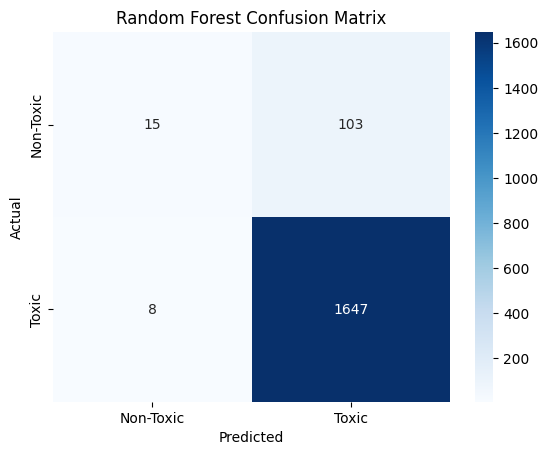

Decision Tree Model Accuracy: 0.91
Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.32      0.36      0.34       118
           1       0.95      0.95      0.95      1655

    accuracy                           0.91      1773
   macro avg       0.64      0.65      0.65      1773
weighted avg       0.91      0.91      0.91      1773



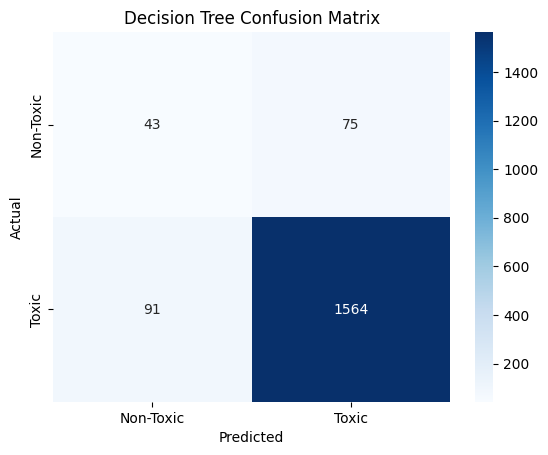

In [ ]:
# Evaluate the Models

def evaluate_model(y_test, y_pred, model_name):
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{model_name} Model Accuracy: {accuracy:.2f}")
    print(f"{model_name} Classification Report:")
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Toxic", "Toxic"], yticklabels=["Non-Toxic", "Toxic"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

evaluate_model(y_test, y_pred_rf, "Random Forest")
evaluate_model(y_test, y_pred_dt, "Decision Tree")

## Plot Decision Tree

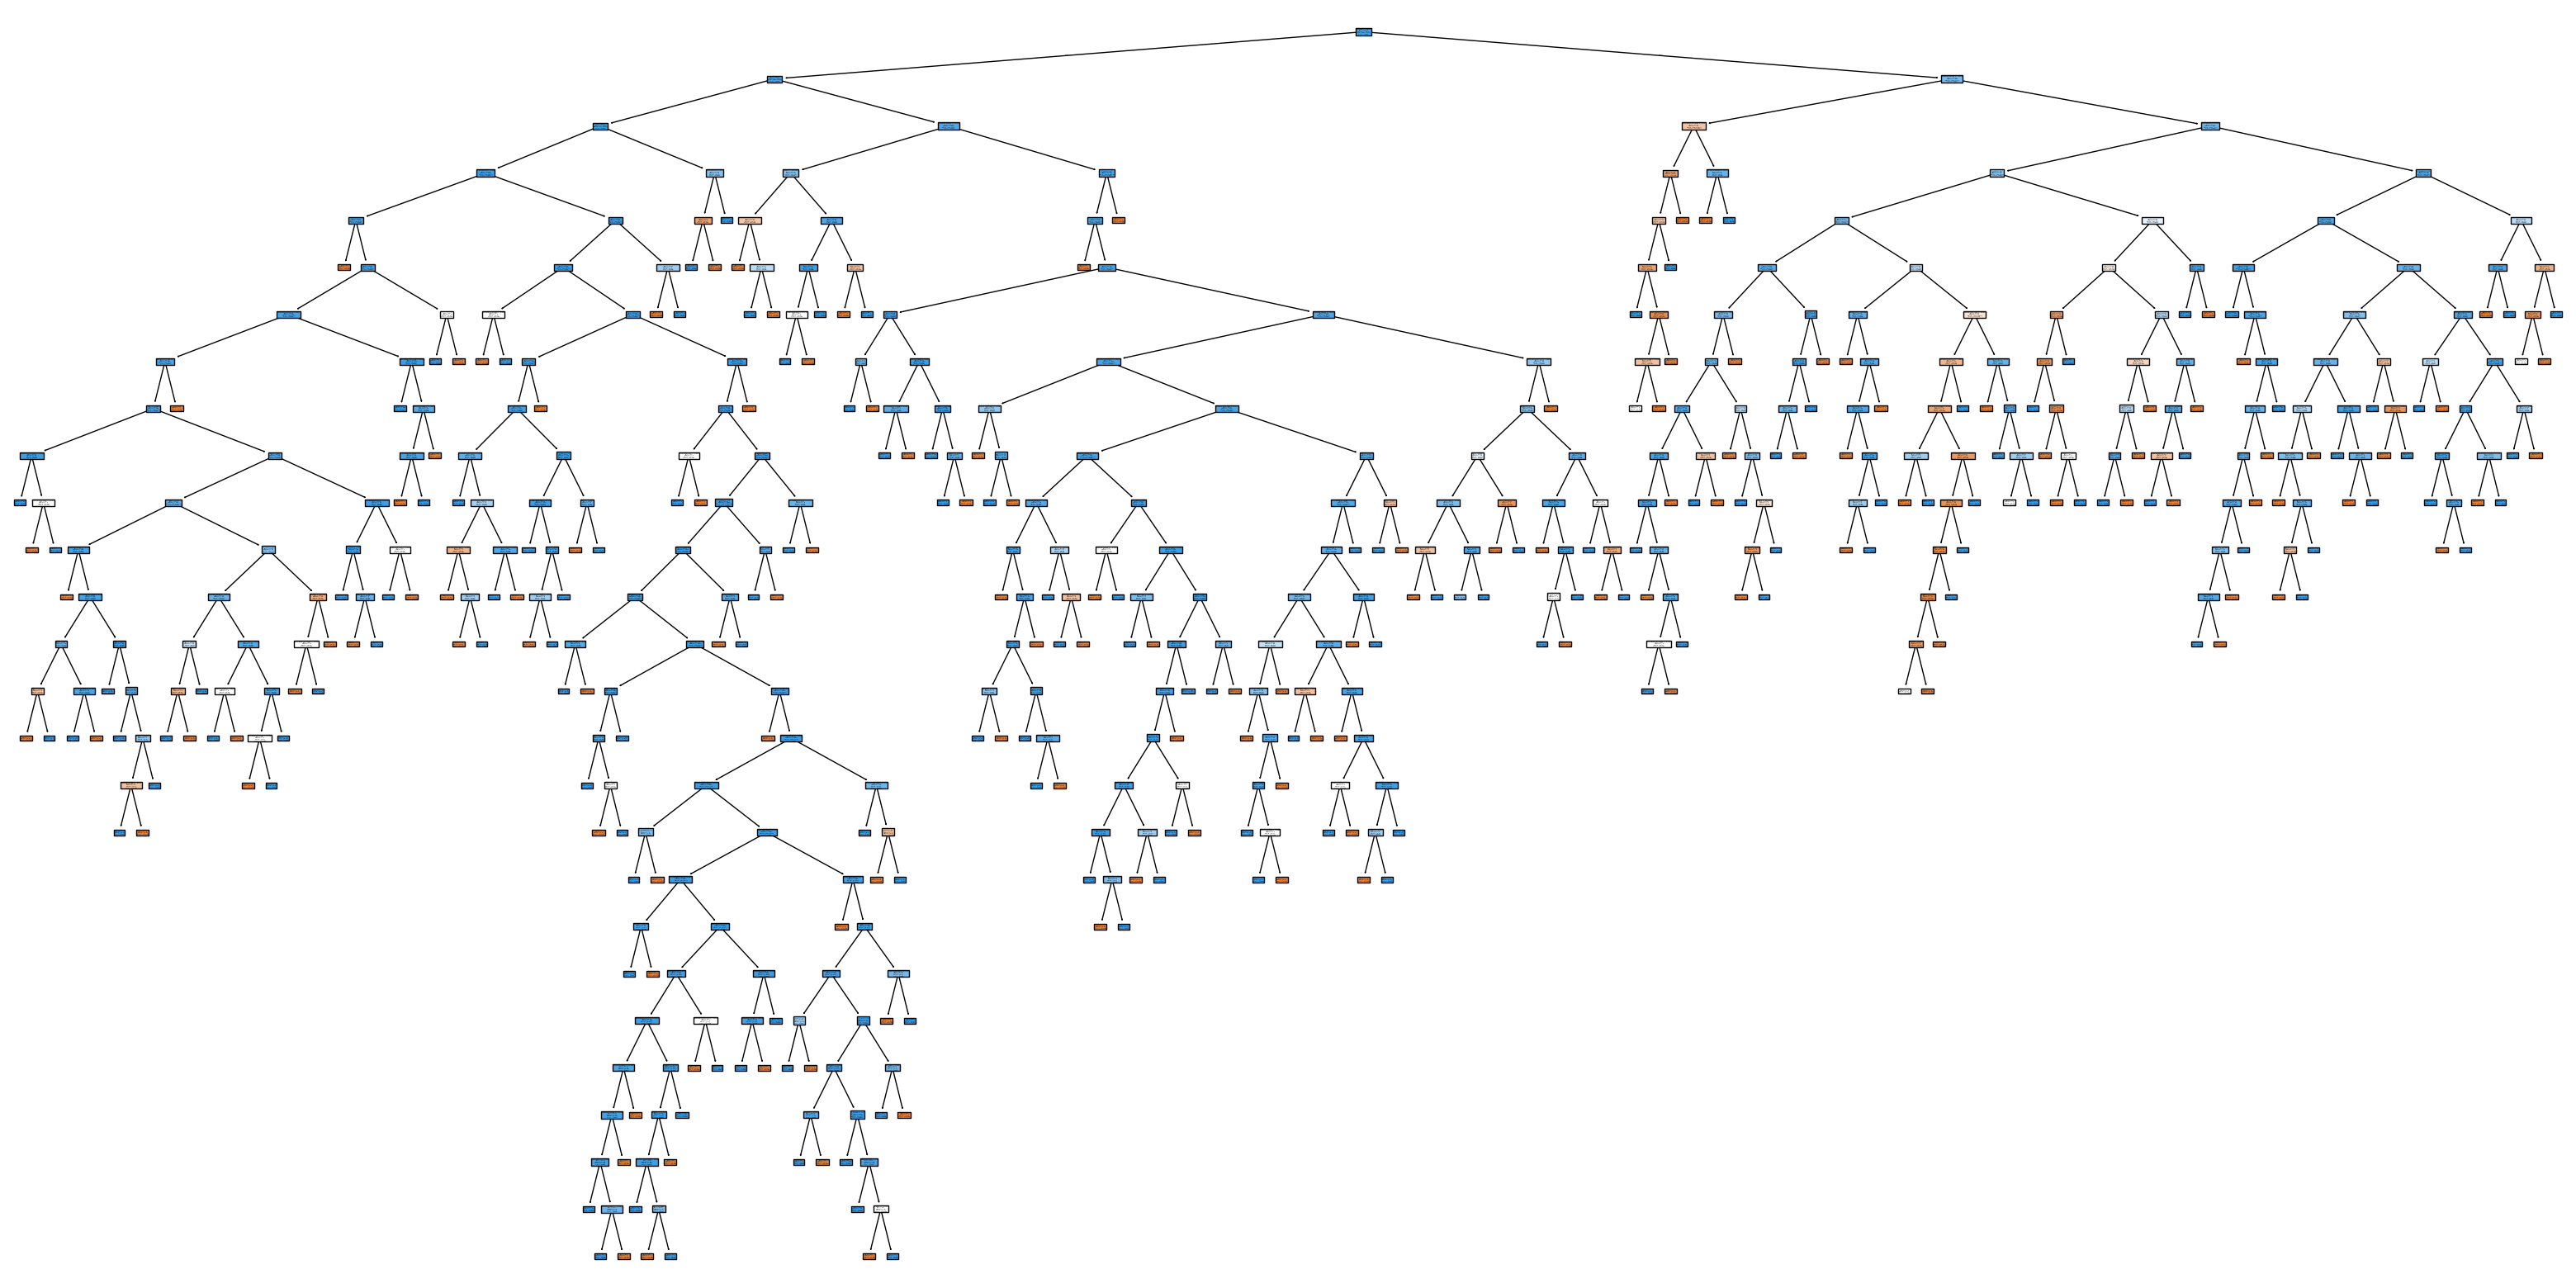

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Plot the decision tree
plt.figure(figsize=(40,20))
plot_tree(clf, feature_names=X_train.columns, class_names=['Inactive', 'Active'], filled=True)

plt.show()

# Vizualizacija molekula

- function takes a molecule, calculates its fingerprint, and then visually highlights the parts of the molecule that correspond to specific bits in the fingerprint that you've chosen. This helps to understand which structural features are captured by those particular fingerprint bits, providing insights into the relationship between molecular structure and the fingerprint representation.



In [ ]:
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import SVG

In [ ]:
# Definiramo funkciju za vizualizaciju substruktura
# smiles: A string representing the molecule in SMILES format
# bitovi: A list of bit positions (integers) in the molecular fingerprint that you want to highlight

def vizualiziraj_substrukture(smiles, bitovi):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    info = {}
    fp = rdMolDescriptors.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=64, bitInfo=info) #calculates the Morgan fingerprint of the molecule

    # Generiranje slike molekule
    drawer = rdMolDraw2D.MolDraw2DSVG(250, 250)
    # Možete koristiti MolDraw2DCairo za PNG

    # Identifying Atoms - Izvlačenje informacija o substrukturi
    atoms_to_highlight = set()
    for bit in bitovi:
        if bit in info:
            # Svaki bit može biti povezan s više fragmenata, pa prođemo kroz sve
            for atom_idx, _ in info[bit]:
                atoms_to_highlight.add(atom_idx)

    # Crtanje molekule
    rdMolDraw2D.PrepareAndDrawMolecule(drawer, mol, highlightAtoms=atoms_to_highlight)
    drawer.FinishDrawing()

    # Prikazivanje crteža
    svg = drawer.GetDrawingText().replace('svg:', '')
    return SVG(svg)

- odabrani_bitovi containing the bit positions (0 through 9) of the fingerprint that you want to highlight in the visualization
- Vizualiziramo substrukture za prvi redak u DataFrame-u
- SMILES string of the 24th molecule (index 23) in your df DataFrame

[19:46:58] DEPRECATION WARNING: please use MorganGenerator


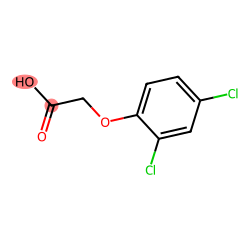

In [ ]:
# Pretpostavljamo da 'df' je vaš DataFrame i da 'standard_smiles' je stupac sa SMILES nizovima
# Odaberite molekulu i bitove koji će biti istaknuti

odabrani_bitovi = [0,1,2,3,4,5,6,7,8,9]
# Zamijenite s bitovima koji vas zanimaju

# Vizualiziramo substrukture za prvi redak u DataFrame-u
# SMILES string of the 24th molecule (index 23) in your df DataFrame.
svg = vizualiziraj_substrukture(df.iloc[23]['standard_SMILES'], odabrani_bitovi)
display(svg)

- for visualizing the chemical structures of the first five molecules in your dataset - It uses the RDKit library to achieve this.

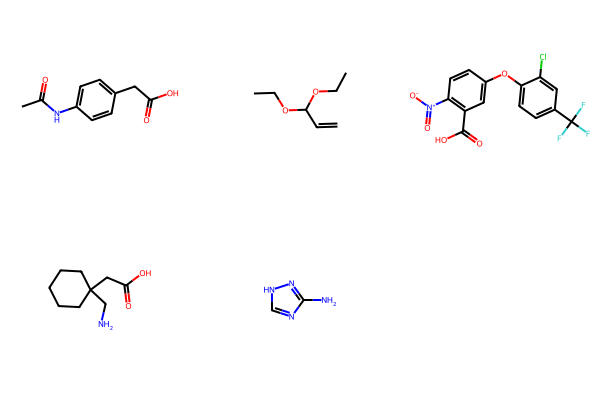

In [ ]:
smis = df['SMILES'][0:5]
# Access the 'SMILES' column using bracket notation
# [0:5]: This part selects the first five rows (indices 0 to 4) of the 'SMILES' column

ms = [Chem.MolFromSmiles(x) for x in smis]
Draw.MolsToGridImage(ms)

 - this code is designed to visualize the parts of a molecule that contribute to its "fingerprint", which is a way of representing its chemical structure in a computer-readable format.

Vizualizacija za molekulu 6


[18:25:49] DEPRECATION WARNING: please use MorganGenerator


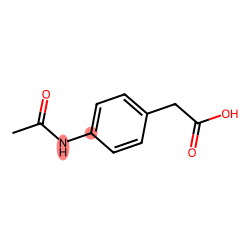

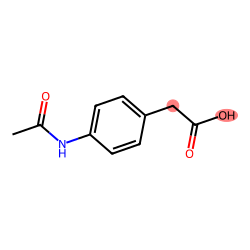

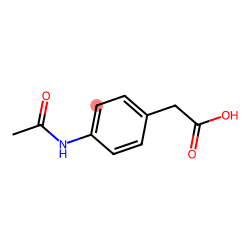

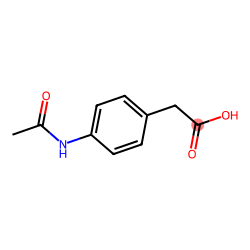

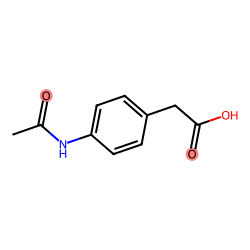

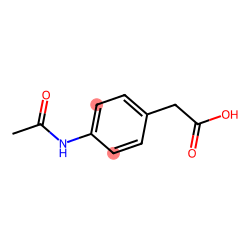

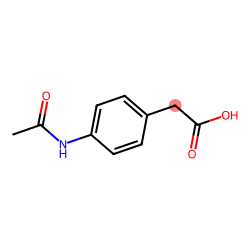

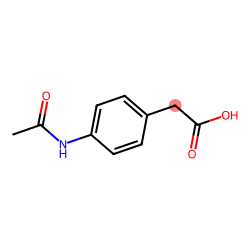

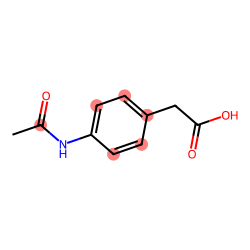

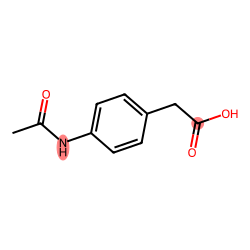

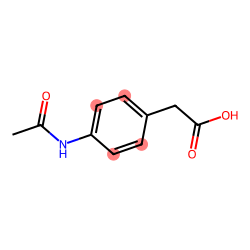

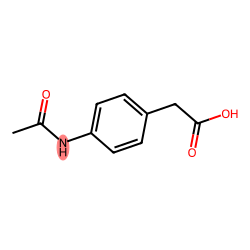

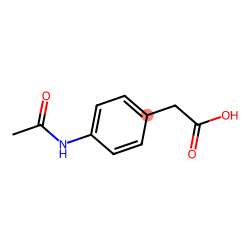

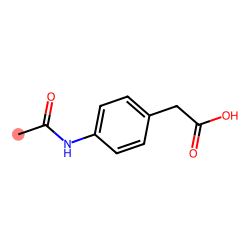

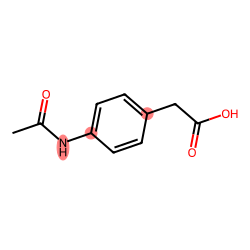

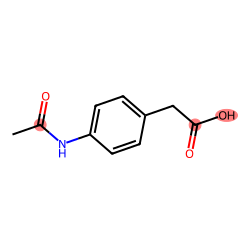

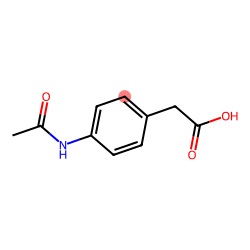

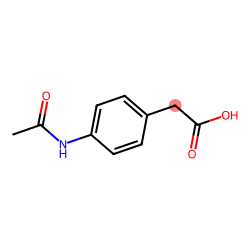

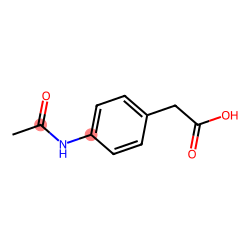

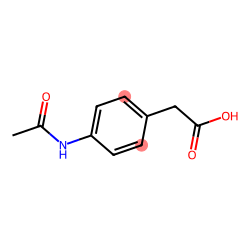

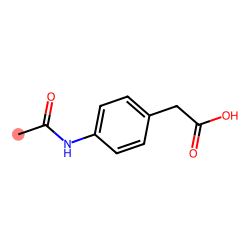

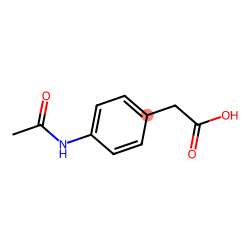

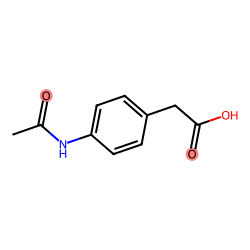

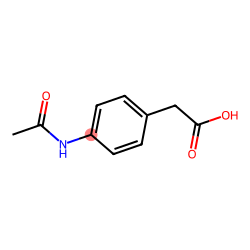

In [ ]:
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import SVG, display

# Pretpostavimo da 'df' je vaš DataFrame i da 'standard_smiles' je stupac sa SMILES nizovima
# Definiramo funkciju za vizualizaciju svih pozitivnih bitova u otisku prsta
def vizualiziraj_sve_pozitivne_bitove(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # Izračunaj fingerprint sa informacijama o bitovima
    info = {}
    fp = rdMolDescriptors.GetMorganFingerprintAsBitVect(mol, radius=3, nBits=64, bitInfo=info)

    # Generiraj sliku molekule za svaki bit koji je 'on'
    for bit in info:
        drawer = rdMolDraw2D.MolDraw2DSVG(250, 250)
        atoms_to_highlight = list(set([pair[0] for pair in info[bit]]))

        rdMolDraw2D.PrepareAndDrawMolecule(drawer, mol, highlightAtoms=atoms_to_highlight)
        drawer.FinishDrawing()

        svg = drawer.GetDrawingText().replace('svg:', '')
        display(SVG(svg))

# Vizualiziraj sve pozitivne bitove za svaku molekulu u DataFrame-u
for index, row in df.iterrows():
    print(f"Vizualizacija za molekulu {index + 6}")
    vizualiziraj_sve_pozitivne_bitove(row['standard_smiles'])
    break


In [ ]:
pip install py3Dmol

- fetching a protein structure from the PDB database, styling it for visual clarity, and then displaing it as an interactive 3D model in  Jupyter notebook

In [ ]:
#4gqs - Structure of Human Microsomal Cytochrome P450 (CYP) 2C19
import py3Dmol
view = py3Dmol.view(query='pdb:4gqs')
view.setStyle({'cartoon':{'color':'spectrum'}})
view

3Dmol.js failed to load for some reason. Please check your browser console for error messages.